<a href="https://colab.research.google.com/github/jtelhu/Data-Science-Project/blob/main/Final_Project_108_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Makes a Song Popular?
**Author:** Justin Telhu
**Course:** CSC 108 / MATH 080 — Spring 2026
**GitHub Repo:** https://github.com/jtelhu/Data-Science-Project

## Problem Statement
This project analyzes audio features of songs from Spotify to identify what makes a song popular. The goal is to build classifiers (Logistic Regression and Random Forest) that predict whether a song will be popular based on its audio features such as Danceability, Energy, and Loudness. The two datasets used are a 900-song general playlist (used as the "non-popular" baseline) and a Top 100 Most Streamed Songs playlist (used as the "popular" sample).

## Data Description
Both datasets were exported using Exportify from Spotify. Each row is a song with metadata (artist, track name) and Spotify's audio features (danceability, energy, valence, acousticness, etc.).

In [27]:
# @title
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# @title
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)

In [3]:
# @title
# Load both datasets
Padding = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Another_10000_songs.csv')
Top100 = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Top_100_Most-Streamed_Songs_on_Spotify.csv')

print("Padding shape:", Padding.shape)
print("Top100 shape:", Top100.shape)

Padding shape: (9985, 24)
Top100 shape: (100, 24)


## Section 2 — Data Cleaning

I take the first 900 songs from the larger playlist (Padding) to keep the dataset balanced. Non-audio columns (track names, artist names, IDs, dates) are dropped because the goal is to predict popularity from audio features. I keep all numerical audio features.

In [4]:
#Take random 1000 songs from Padding
Padding1k = Padding.head(900).copy()

# Drop non-audio identifier columns
columns_to_drop = ['Track URI', 'Album Name', 'Added By', 'Added At',
                   'Genres', 'Record Label', 'Release Date']

Padding_cleaned = Padding1k.drop(columns=columns_to_drop, errors='ignore')
Top100_cleaned = Top100.drop(columns=columns_to_drop, errors='ignore')

audio_features = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Speechiness',
                  'Instrumentalness', 'Liveness', 'Loudness', 'Tempo', 'Key', 'Mode',
                  'Time Signature', 'Duration (min)', 'Explicit']

# Convert Explicit to 0/1
Padding_cleaned['Explicit'] = Padding_cleaned['Explicit'].astype(int)
Top100_cleaned['Explicit'] = Top100_cleaned['Explicit'].astype(int)

# Convert Duration from ms to minutes
Padding_cleaned['Duration (min)'] = Padding_cleaned['Duration (ms)'] / 60000
Top100_cleaned['Duration (min)'] = Top100_cleaned['Duration (ms)'] / 60000
Padding_cleaned = Padding_cleaned.drop(columns=['Duration (ms)'])
Top100_cleaned = Top100_cleaned.drop(columns=['Duration (ms)'])

print("Same columns?", set(Padding_cleaned.columns) == set(Top100_cleaned.columns))
print("Padding_cleaned shape:", Padding_cleaned.shape)
print("Top100_cleaned shape:", Top100_cleaned.shape)

Same columns? True
Padding_cleaned shape: (900, 17)
Top100_cleaned shape: (100, 17)


In [5]:
# Find and remove tracks that appear in both datasets
overlap = pd.merge(Padding_cleaned[['Track Name', 'Artist Name(s)']], Top100_cleaned[['Track Name', 'Artist Name(s)']], on=['Track Name', 'Artist Name(s)'])
print('Overlapping tracks found:', len(overlap))

before = len(Padding_cleaned)
Padding_cleaned = Padding_cleaned.merge(
    Top100_cleaned[['Track Name', 'Artist Name(s)']], on=['Track Name', 'Artist Name(s)'], how='left', indicator=True
)
Padding_cleaned = Padding_cleaned[Padding_cleaned['_merge'] == 'left_only'].drop(columns=['_merge'])
print(f"Padding before: {before} songs, after: {len(Padding_cleaned)} songs")

Overlapping tracks found: 11
Padding before: 900 songs, after: 889 songs


## Section 3 — Exploratory Data Analysis

Energy and Loudness are strongly positively correlated, while Acousticness is negatively correlated with both.

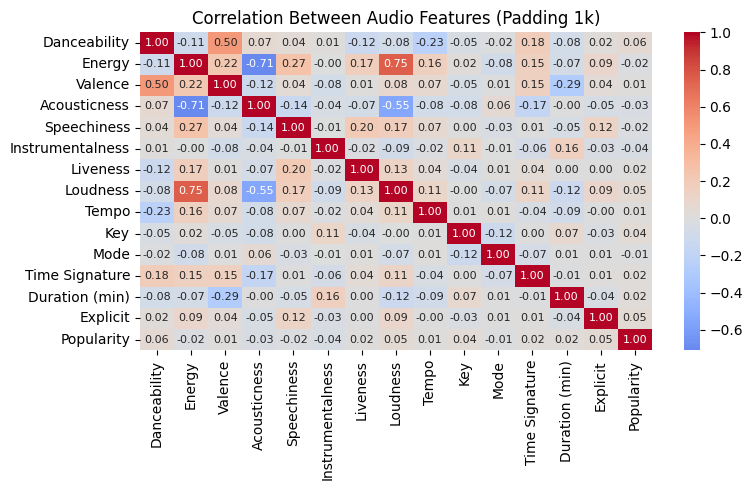

In [6]:
# @title
# Correlation heatmap on the larger Padding dataset
audio_features_plus_popularity = audio_features + ['Popularity']
plt.figure(figsize=(8, 5))
sns.heatmap(Padding_cleaned[audio_features_plus_popularity].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 8})
plt.title('Correlation Between Audio Features (Padding 1k)')
plt.tight_layout()
plt.show()

## Section 4 — Comparing Popular vs. General Songs (T-tests)
 Before building classifiers, Im comparing the audio feature distributions between popular (Top 100) and general songs. Welch's t-tests flag which features differ significantly between the two groups, and boxplots show the same comparison visually. the same features tend to appear as the strongest predictors.

In [24]:
# T-tests on each feature
significant_features = []
results = []

for feature in audio_features:
    top_vals = Top100_cleaned[feature]
    gen_vals = Padding_cleaned[feature]
    stat, p_value = ttest_ind(top_vals, gen_vals, equal_var=False)
    is_sig = p_value < 0.05
    if is_sig:
        significant_features.append(feature)
    results.append({
        'Feature': feature,
        'Mean (Top 100)': round(top_vals.mean(), 3),
        'Mean (General)': round(gen_vals.mean(), 3),
        'T-statistic': round(stat, 3),
        'P-value': round(p_value, 5),
        'Significant?': 'Yes' if is_sig else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string())
print(f"\nFeatures with statistically significant differences (p < 0.05):")
print(significant_features)

             Feature  Mean (Top 100)  Mean (General)  T-statistic  P-value Significant?
0       Danceability           0.618           0.532        5.481  0.00000          Yes
1             Energy           0.633           0.715       -4.309  0.00003          Yes
2            Valence           0.491           0.510       -0.752  0.45370           No
3       Acousticness           0.232           0.180        1.802  0.07409           No
4        Speechiness           0.078           0.061        1.994  0.04868          Yes
5   Instrumentalness           0.010           0.070       -8.114  0.00000          Yes
6           Liveness           0.171           0.194       -1.630  0.10549           No
7           Loudness          -6.430          -7.077        2.524  0.01265          Yes
8              Tempo         119.825         124.298       -1.431  0.15513           No
9                Key           4.850           5.340       -1.251  0.21333           No
10              Mode           0

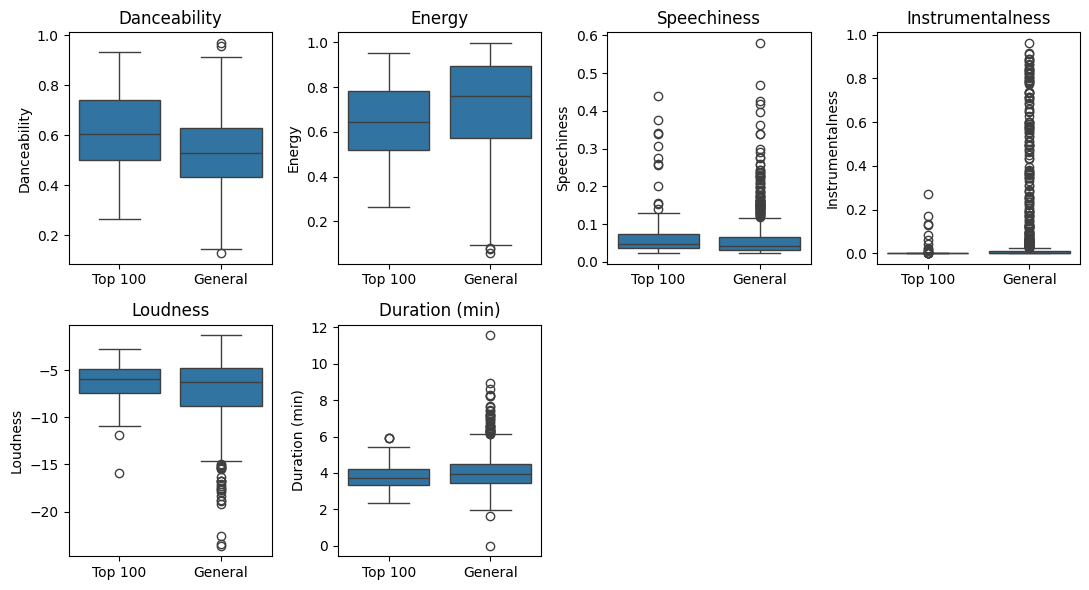

In [8]:
# Boxplots for the significant features (excluding binary Explicit)
Top100_cleaned['Group'] = 'Top 100'
Padding_cleaned['Group'] = 'General'
combined_df = pd.concat([Top100_cleaned, Padding_cleaned], ignore_index=True)

quantitative_significant_features = [f for f in significant_features if f != 'Explicit']
n = len(quantitative_significant_features)
cols = 4
rows = (n + cols - 1) // cols

plt.figure(figsize=(11, 3 * rows))
for i, feature in enumerate(quantitative_significant_features):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x='Group', y=feature, data=combined_df)
    plt.title(f'{feature}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

Top100_cleaned = Top100_cleaned.drop(columns=['Group'])
Padding_cleaned = Padding_cleaned.drop(columns=['Group'])

## Section 5 — Building the Classifiers

I combine both datasets, create a binary `is_popular` label using a Popularity threshold of 50, and split the data 80/20 into training and testing sets. The features are then standardized for Logistic Regression. The split is with stratification (preserves class balance in both halves) and scales features for Logistic Regression. Scaler is fit on training data only to avoid leakage.

In [9]:
# Combine the datasets
combined = pd.concat([Padding_cleaned, Top100_cleaned], ignore_index=True)
combined = combined.dropna(subset=['Popularity'])

# Create binary label using a meaningful threshold
THRESHOLD = 50
combined['is_popular'] = (combined['Popularity'] >= THRESHOLD).astype(int)

print(f"Combined dataset shape: {combined.shape}")
print(f"Threshold: Popularity >= {THRESHOLD}")
print(f"\nClass balance:")
print(combined['is_popular'].value_counts())
print(f"Proportion popular: {combined['is_popular'].mean():.2%}")

Combined dataset shape: (989, 18)
Threshold: Popularity >= 50

Class balance:
is_popular
0    612
1    377
Name: count, dtype: int64
Proportion popular: 38.12%


In [10]:
# Train/test split with stratification
X = combined[audio_features]
y = combined['is_popular']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Scale features for Logistic Regression (fit on training only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} songs")
print(f"Testing set:  {X_test.shape[0]} songs")

Training set: 791 songs
Testing set:  198 songs


## Section 6 — Logistic Regression

Logistic Regression fits a linear decision boundary on the scaled features.
- **Test accuracy** — the simple share of correct predictions
- **Test AUC** — the area under the ROC curve, which measures how well the model ranks popular songs above non-popular ones across all possible thresholds
- **Coefficients** — which features push predictions toward "popular" (positive) or "not popular" (negative)

Trains Logistic Regression on the scaled training data and reports both accuracy and AUC on the test set. AUC is the key metric because it captures model quality across all decision thresholds.

In [11]:
# Train Logistic Regression
logModel = LogisticRegression(max_iter=100, class_weight='balanced')
logModel.fit(X_train_scaled, y_train)

# Predictions and probabilities
log_pred = logModel.predict(X_test_scaled)
log_prob = logModel.predict_proba(X_test_scaled)[:, 1]  # probability of class 1

log_acc = accuracy_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_prob)

print(f"Logistic Regression Test Accuracy: {log_acc:.4f}")
print(f"Logistic Regression Test AUC:      {log_auc:.4f}")
print()
print(classification_report(y_test, log_pred, target_names=['Not Popular', 'Popular']))

Logistic Regression Test Accuracy: 0.6061
Logistic Regression Test AUC:      0.6559

              precision    recall  f1-score   support

 Not Popular       0.71      0.63      0.66       123
     Popular       0.48      0.57      0.52        75

    accuracy                           0.61       198
   macro avg       0.59      0.60      0.59       198
weighted avg       0.62      0.61      0.61       198



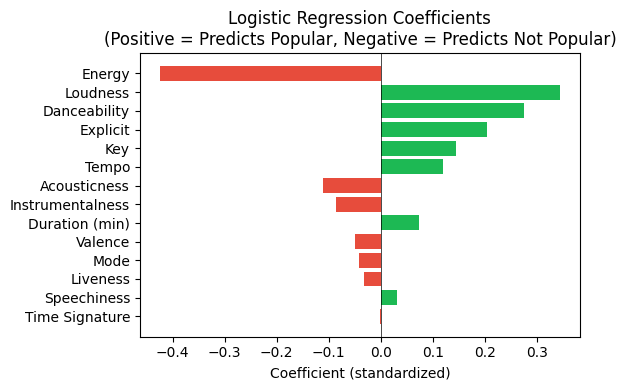

In [23]:
# Logistic Regression coefficients
log_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logModel.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(6, 4))
colors = ['#1DB954' if c > 0 else '#E74C3C' for c in log_coef_df['Coefficient']]
plt.barh(log_coef_df['Feature'], log_coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient (standardized)')
plt.title('Logistic Regression Coefficients\n(Positive = Predicts Popular, Negative = Predicts Not Popular)')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Section 7 — Random Forest

Random Forest captures non-linear relationships and feature interactions that Logistic Regression can't. There are the same metrics (test accuracy, test AUC) plus a confusion matrix and feature importance ranking.

In [14]:
# Train Random Forest
rfModel = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfModel.fit(X_train, y_train)

# Predictions and probabilities
rf_pred = rfModel.predict(X_test)
rf_prob = rfModel.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest Test Accuracy: {rf_acc:.4f}")
print(f"Random Forest Test AUC:      {rf_auc:.4f}")
print()
print(classification_report(y_test, rf_pred, target_names=['Not Popular', 'Popular']))

Random Forest Test Accuracy: 0.6414
Random Forest Test AUC:      0.6401

              precision    recall  f1-score   support

 Not Popular       0.65      0.90      0.76       123
     Popular       0.57      0.21      0.31        75

    accuracy                           0.64       198
   macro avg       0.61      0.56      0.53       198
weighted avg       0.62      0.64      0.59       198



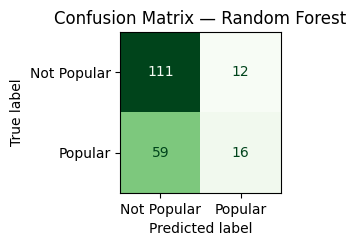

In [28]:
# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Popular', 'Popular'])

fig, ax = plt.subplots(figsize=(3, 3))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

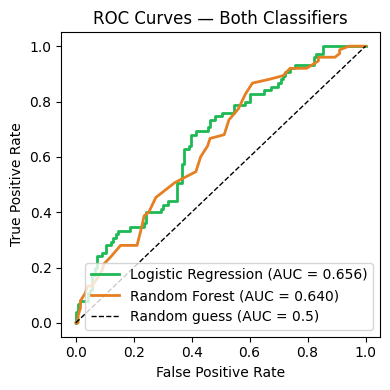

In [16]:
# ROC curve for Random Forest (and overlay with Logistic Regression)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(4, 4))
plt.plot(fpr_log, tpr_log, color='#1DB954', linewidth=2, label=f'Logistic Regression (AUC = {log_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#E67E22', linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Both Classifiers')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Comparing the Random Forest's top features with the largest Logistic Regression coefficients shows whether both methods agree on which features matter. Agreement across two different methods is stronger evidence than a single model's output.

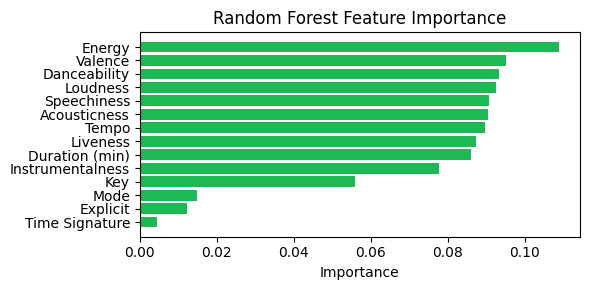

In [17]:
# Random Forest feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfModel.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 3))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1DB954')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
#display(importance_df)

## Section 8 — Threshold Analysis (Precision vs. Recall)

The default decision threshold for both classifiers is 0.5: predict "popular" if the model's predicted probability is above 0.5. But the threshold is a choice, and moving it changes the tradeoff between **precision** (when the model says "popular," how often is it right?) and **recall** (out of all actually popular songs, how many did we catch?).

- **Lower threshold** → more songs labeled "popular" → recall up, precision down
- **Higher threshold** → fewer songs labeled "popular" → precision up, recall down

This is why AUC is a more honest metric than accuracy at a single threshold  AUC summarizes performance across every possible threshold.

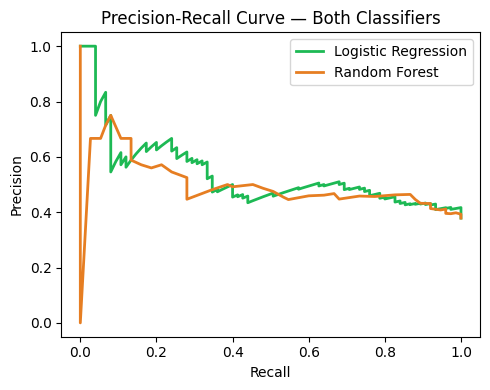

In [18]:
# Precision-Recall curve for Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_prob)
precision_log, recall_log, thresholds_log = precision_recall_curve(y_test, log_prob)

plt.figure(figsize=(5, 4))
plt.plot(recall_log, precision_log, color='#1DB954', linewidth=2, label='Logistic Regression')
plt.plot(recall_rf, precision_rf, color='#E67E22', linewidth=2, label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Both Classifiers')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

several threshold values and shows precision, recall, F1, and how many songs are labeled "popular" at each. This makes the precision–recall tradeoff concrete.*

At the default 0.5 threshold, the classifier is conservative — it only labels songs "popular" when it is very confident, so it has high precision but low recall. Lowering the threshold catches more of the actually-popular songs but introduces more false positives. The right threshold depends on whether about avoiding false alarms (high threshold) or about not missing popular songs (low threshold).

In [19]:
# Show precision/recall at several thresholds for Random Forest
print("Random Forest precision/recall at different thresholds:\n")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'# Predicted Popular':>22}")
print("-" * 70)
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (rf_prob >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    n_pred_pos = (preds == 1).sum()
    print(f"{t:>10.2f} {precision:>10.3f} {recall:>10.3f} {f1:>10.3f} {n_pred_pos:>22}")

Random Forest precision/recall at different thresholds:

 Threshold  Precision     Recall         F1    # Predicted Popular
----------------------------------------------------------------------
      0.20      0.398      0.987      0.567                    186
      0.30      0.432      0.893      0.583                    155
      0.40      0.446      0.547      0.491                     92
      0.50      0.545      0.240      0.333                     33
      0.60      0.714      0.067      0.122                      7
      0.70      0.000      0.000      0.000                      0


## Section 9 — Tuning the Random Forest

I run a grid search over combinations of `n_estimators` (number of trees) and `max_depth` (how deep each tree grows) to see whether the default settings can be improved.

In [26]:
# Grid search over hyperparameters
n_estimators_grid = [50, 100, 200, 500]
max_depth_grid = [5, 10, 20, None]

tuning_results = []
for n_est in n_estimators_grid:
    for max_d in max_depth_grid:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42, class_weight='balanced')
        rf.fit(X_train, y_train)
        prob = rf.predict_proba(X_test)[:, 1]
        acc = accuracy_score(y_test, rf.predict(X_test))
        auc = roc_auc_score(y_test, prob)
        tuning_results.append({
            'n_estimators': n_est,
            'max_depth': str(max_d),
            'Test Accuracy': round(acc, 4),
            'Test AUC': round(auc, 4)
        })

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.to_string(index=False))
best = tuning_df.loc[tuning_df['Test AUC'].idxmax()]
print(f"\nBest by AUC: n_estimators={best['n_estimators']}, max_depth={best['max_depth']}")
print(f"Best test AUC: {best['Test AUC']:.4f}")

 n_estimators max_depth  Test Accuracy  Test AUC
           50         5         0.6313    0.6741
           50        10         0.6717    0.6747
           50        20         0.6566    0.6538
           50      None         0.6465    0.6376
          100         5         0.6263    0.6893
          100        10         0.6717    0.6720
          100        20         0.6364    0.6438
          100      None         0.6414    0.6401
          200         5         0.6515    0.6864
          200        10         0.6465    0.6710
          200        20         0.6263    0.6271
          200      None         0.6313    0.6164
          500         5         0.6616    0.6776
          500        10         0.6515    0.6663
          500        20         0.6313    0.6494
          500      None         0.6465    0.6377

Best by AUC: n_estimators=100, max_depth=5
Best test AUC: 0.6893


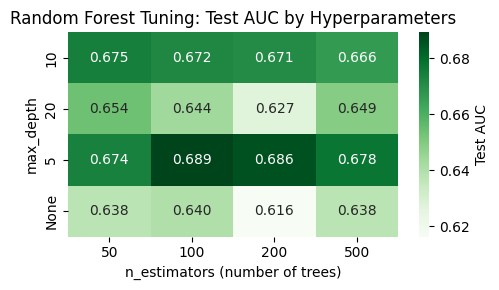

In [21]:
# Heatmap of tuning results by AUC
heatmap_data = tuning_df.pivot(index='max_depth', columns='n_estimators', values='Test AUC')

plt.figure(figsize=(5, 3))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Greens', cbar_kws={'label': 'Test AUC'})
plt.title('Random Forest Tuning: Test AUC by Hyperparameters')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

## Section 10 — Conclusion

This project built two classifiers to predict whether a Spotify song is popular based on its audio features.

**What was done.** A 900-song general playlist was combined with a Top 100 most-streamed playlist (with overlapping tracks deduplicated). T-tests identified which audio features differ significantly between popular and general songs. Two classifiers — Logistic Regression and Random Forest — were trained on a binary "popular" label (Popularity ≥ 50) using an 80/20 train/test split. Both classifiers were evaluated using accuracy and AUC, and the threshold tradeoff between precision and recall was examined directly.

**What was found.** The t-tests identified seven features as significantly different between popular and general songs (p < 0.05): Danceability, Energy, Speechiness, Instrumentalness, Loudness, Duration, and Explicit. Popular songs have *higher* Danceability but *lower* Energy than general songs, meaning popular tracks tend to be less intense.

Logistic Regression achieved a test AUC of 0.656 and Random Forest achieved 0.640. After tuning, the best Random Forest reached AUC 0.689 with n_estimators=100, max_depth=5. Each model clears the 0.5 random-guess baseline, meaning audio features carry real predictive signal — but the signal is modest. The confusion matrix for Random Forest shows that the model still tends to classify songs as 'not popular' by default; this is a consequence of the class imbalance in the data (about 38% popular vs 62% not popular).

The threshold analysis demonstrates that precision and recall trade off directly: at the default 0.5 threshold the model is conservative (high precision, low recall), but lowering the threshold catches more popular songs at the cost of more false positives. There is no single "right" threshold — the choice depends on what kind of mistake matters more in a given application.

Both Logistic Regression coefficients and Random Forest feature importance rank Danceability, Energy, and Loudness near the top. Two different methods agreeing on the same features is strong evidence that these are the audio features most associated with popularity in this dataset.

**Limitations.**
- Sample size is roughly 1,000 songs total. A larger and better-balanced dataset would give stronger results.
- Audio features only describe how a song *sounds*. Marketing, social media virality, and artist fame also drive popularity but aren't captured here.
- The Popularity ≥ 50 threshold is one reasonable choice; results may differ at other thresholds.

** note.** Features were standardized using StandardScaler before fitting Logistic Regression. This ensures that features measured on different scales (Loudness in dB, Tempo in BPM, Danceability on a 0–1 scale) contribute equally to the model and that coefficients are comparable across features. Random Forest does not require scaling. Without class weighting the classifier was degenerate, it always predicted Not Popular. Class weighting forces the model to give equal importance to both classes, which makes the predictions actually meaningful even if overall accuracy drops slightly."

## Team Sharing Statement

This project was completed individually

## Project Sharing Statement

This project may be shared with future classes.